In [1]:
import pandas as pd

df = pd.read_csv("Social_Network_Ads.csv")

print("--- أول 5 صفوف من البيانات ---")
display(df.head())

print("\n--- حجم البيانات (أسطر، أعمدة) ---")
print(df.shape)

print("\n--- تفاصيل الأعمدة وأنواع البيانات ---")
df.info()

--- أول 5 صفوف من البيانات ---


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0



--- حجم البيانات (أسطر، أعمدة) ---
(400, 3)

--- تفاصيل الأعمدة وأنواع البيانات ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["Age", "EstimatedSalary"]].values
y = df["Purchased"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("عدد عينات التدريب (X_train):", X_train.shape[0])
print("عدد عينات الاختبار (X_test):", X_test.shape[0])

عدد عينات التدريب (X_train): 280
عدد عينات الاختبار (X_test): 120


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

weights = model.coef_[0]
bias = model.intercept_[0]

print("تم تدريب النموذج بنجاح!")
print("--- الأوزان والانحياز الناتجة ---")
print(f"كفة العمر (w1): {weights[0]:.4f}")
print(f"كفة الراتب (w2): {weights[1]:.4f}")
print(f"قيمة الانحياز (Bias / b): {bias:.4f}")

تم تدريب النموذج بنجاح!
--- الأوزان والانحياز الناتجة ---
كفة العمر (w1): 1.8662
كفة الراتب (w2): 1.0463
قيمة الانحياز (Bias / b): -1.0958


In [5]:
y_pred = model.predict(X_test)

print("أول 10 توقعات للنموذج (y_pred):")
print(y_pred[:10])

print("\nالإجابات الحقيقية للـ 10 أشخاص دول (y_test):")
print(y_test[:10])

أول 10 توقعات للنموذج (y_pred):
[0 1 0 1 0 0 1 0 0 0]

الإجابات الحقيقية للـ 10 أشخاص دول (y_test):
[0 1 0 1 0 0 1 0 0 0]


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print(f"دقة النموذج (Accuracy): {accuracy * 100:.2f}%")
print("\n--- مصفوفة الارتباك (Confusion Matrix) ---")
print(cm)

دقة النموذج (Accuracy): 85.00%

--- مصفوفة الارتباك (Confusion Matrix) ---
[[71  2]
 [16 31]]


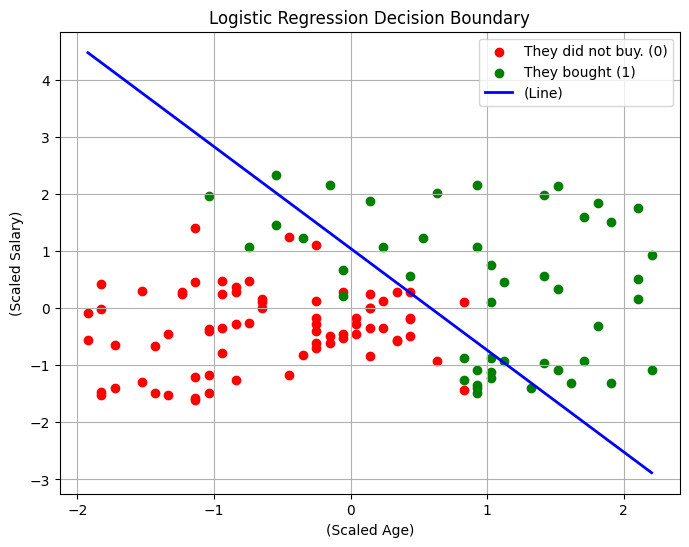

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[y_test == 0, 0],
    X_test[y_test == 0, 1],
    color="red",
    label="They did not buy. (0)",
)
plt.scatter(
    X_test[y_test == 1, 0],
    X_test[y_test == 1, 1],
    color="green",
    label="They bought (1)",
)

x1_vals = np.array([X_test[:, 0].min(), X_test[:, 0].max()])
x2_vals = -(weights[0] * x1_vals + bias) / weights[1]

plt.plot(x1_vals, x2_vals, color="blue", linewidth=2, label="(Line)")

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("(Scaled Age)")
plt.ylabel("(Scaled Salary)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np


new_person = np.array([[45, 90000]])

new_person_scaled = scaler.transform(new_person)

prediction = model.predict(new_person_scaled)

probability = model.predict_proba(new_person_scaled)

print("--- نتيجة التوقع للشخص الجديد ---")
if prediction[0] == 1:
    print("التوقع: الشخص ده (bought ) المنتج ")
else:
    print("التوقع: الشخص ده (did not buy) المنتج ")

print(f"احتمالية الشراء: {probability[0][1] * 100:.2f}%")

--- نتيجة التوقع للشخص الجديد ---
التوقع: الشخص ده (bought ) المنتج 
احتمالية الشراء: 70.37%
